# OrbitFinder RESI Cross — Helium

Reproduces the RESI "cross" signature from Shaaran, Nygren & Figueira de Morisson Faria,
*Phys. Rev. A* 81, 063413 (2010), Fig. 2(c)/Fig. 4: Helium ($E_{1g}=0.97$, $E_{2g}=2.0$,
$E_{2e}=0.5$ a.u.), $\omega=0.057$ a.u. ($\approx 800$nm), $I=3\times10^{14}\text{ W/cm}^2$
($U_p=0.6579$ a.u.), all three prefactors constant (the simplest case in the paper).

Config: `OrbitFinder/TestingSuite/helium_resi_cross.inp`. This run only became possible after
fixing the `ResultGrid`/`AggregateChannels` crash (mismatched short/long orbit table sizes
when the saddle-point solver failed to converge at some grid points).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = "/workspaces/CQSFA/OrbitFinder/TestingSuite/results"
DATA_FILE = f"{RESULTS_DIR}/helium_resi_cross.inpPre_0_Range_29X29_Up_0_ChannelSum_0_Coh.LRUD"

Up = 0.6579  # a.u., from I=3e14 W/cm^2 at omega=0.057 a.u.
p_min, p_max = -3.5, 3.5  # matches %En grid range in helium_resi_cross.inp

data = np.loadtxt(DATA_FILE)
n = int(data[:, 0].max()) + 1
grid = np.zeros((n, n))
for i, j, v in data:
    grid[int(i), int(j)] = v

print(f"Loaded {n}x{n} grid, max probability = {grid.max():.3e}")

Loaded 29x29 grid, max probability = 1.773e-13


## Coherent sum, symmetrised (L/R/U/D) — should show the RESI cross

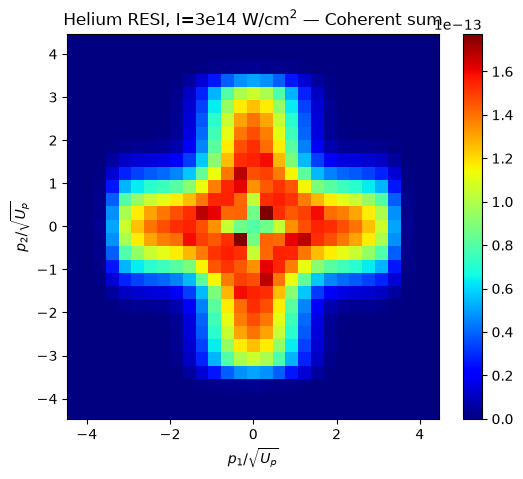

In [2]:
p = np.linspace(p_min, p_max, n) / np.sqrt(Up)

fig, ax = plt.subplots(figsize=(6, 5))
mesh = ax.pcolormesh(p, p, grid.T, cmap="jet", shading="auto")
ax.set_xlabel(r"$p_1 / \sqrt{U_p}$")
ax.set_ylabel(r"$p_2 / \sqrt{U_p}$")
ax.set_title("Helium RESI, I=3e14 W/cm$^2$ — Coherent sum")
plt.colorbar(mesh, ax=ax)
plt.show()

## How the Coulomb potential alters the RESI cross ("Frankenstein" combination)

Combines electron 1's action $S_A$ (from OrbitFinder's own $t_1,t_2$ saddle-point solve, via
`Action::f12`) with electron 2's amplitude computed two ways for comparison:
- **Plain SFA**: OrbitFinder's own $t_3$ solve, via `Action::f3` (no Coulomb potential).
- **Frankenstein**: `CQSFA_fwd`'s full Coulomb-corrected propagation for electron 2, with the
  *same* laser field ($\omega=0.057$, $U_p=0.6579$ a.u.) and $I_p=E_{2e}=0.5$ a.u., $Z=2$ (He$^+$).

Full derivation, formula translation and validation lives in
`AttoPython/CQSFA_Analysis/Frankenstein_Combination.ipynb` (this is the "code that does the
merge", saved there). This cell reproduces the final comparison plot for convenience.

In [7]:
import glob
from matplotlib.colors import LogNorm

OrbitFinder_dir = "/workspaces/CQSFA/OrbitFinder/TestingSuite"
CQSFA_dir = "/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2"

omega = 0.057
Up0 = Up / omega
Ip1, Ip2, Ip12 = 0.97, 2.0, 0.5  # I1g, I2g, I2e (Helium RESI channel)


def f12(e1_long, e1_trans, t1, t2):
    """Electron-1-only action (Action::f12 in OrbitFinder)."""
    p10 = e1_long * np.sqrt(Up0)
    p1tr0 = e1_trans * np.sqrt(Up0)
    ip10, ip120, ip20 = Ip1 / omega, Ip12 / omega, Ip2 / omega
    sin_t1, sin_2t1, sin_t2 = np.sin(t1), np.sin(2 * t1), np.sin(t2)
    X = (sin_t2 - sin_t1) ** 2 / (t2 - t1)
    return (
        t1 * (Up0 + ip10)
        + t2 * (ip20 - ip120 + 0.5 * (p10 ** 2 + p1tr0 ** 2))
        + sin_2t1 * 0.5 * Up0 + sin_t2 * 2 * p10 * np.sqrt(Up0) + X * 2 * Up0
    )


def f3(e2_long, e2_trans, t3):
    """Electron-2-only, pure-SFA action (Action::f3 in OrbitFinder)."""
    p20 = e2_long * np.sqrt(Up0)
    p2tr0 = e2_trans * np.sqrt(Up0)
    ip120 = Ip12 / omega
    return (
        t3 * (0.5 * (p20 ** 2 + p2tr0 ** 2) + Up0 + ip120)
        + np.sin(t3) * p20 * np.sqrt(4 * Up0) + np.sin(2 * t3) * 0.5 * Up0
    )


def bin_onto_grid(p_long, p_trans, values, decimals=3):
    """Bucket scattered (p_long,p_trans,value) rows onto a regular grid, tolerant of tiny
    floating-point jitter in OrbitFinder's printed axis values."""
    long_axis = np.unique(np.round(p_long, decimals))
    trans_axis = np.unique(np.round(p_trans, decimals))
    grid = np.full((len(long_axis), len(trans_axis)), np.nan, dtype=values.dtype)
    i_idx = np.searchsorted(long_axis, np.round(p_long, decimals))
    j_idx = np.searchsorted(trans_axis, np.round(p_trans, decimals))
    grid[i_idx, j_idx] = values
    return long_axis, trans_axis, grid


def mask_and_bin(p_long, p_trans, S, decimals=3):
    """exp(iS), masking Im(S)<0 (unphysical growing amplitude - wrong root at extreme momenta)."""
    with np.errstate(over="ignore"):
        A = np.where(S.imag >= 0, np.exp(1j * S), 0.0)
    return bin_onto_grid(p_long, p_trans, A, decimals)


def symmetrize_1d(axis, W):
    """W_sym(p) = W(p) + W(-p). OrbitFinder's own cross plot applies this kind of L/R sign-flip
    symmetrisation (its %MS option) on top of the p1<->p2 exchange; without it, any left-right
    imbalance in the raw (unsymmetrised) saddle-point solve leaks into the final map as a
    spurious asymmetry that isn't physical (a linearly polarised field has no preferred
    direction along its polarisation axis)."""
    return W + np.interp(-axis, axis, W, left=0.0, right=0.0)


def load_orbit_e1(fname):
    rows = np.loadtxt(fname)
    p_long, p_trans = rows[:, 0], rows[:, 1]
    t1, t2 = rows[:, 2] + 1j * rows[:, 3], rows[:, 4] + 1j * rows[:, 5]
    return mask_and_bin(p_long, p_trans, f12(p_long, p_trans, t1, t2))


def load_orbit_e2_sfa(fname):
    rows = np.loadtxt(fname)
    p_long, p_trans = rows[:, 0], rows[:, 1]
    t3 = rows[:, 6] + 1j * rows[:, 7]
    return mask_and_bin(p_long, p_trans, f3(p_long, p_trans, t3))


# Electron 1 (always SFA, via t1,t2) - coherent sum of short+long orbit branches
p1_par_axis, _, A1_s = load_orbit_e1(f"{OrbitFinder_dir}/results/helium_resi_cross.inp_Range_29X29_channel:0.shortorbit")
_, _, A1_l = load_orbit_e1(f"{OrbitFinder_dir}/results/helium_resi_cross.inp_Range_29X29_channel:0.longorbit")
W1 = (np.abs(np.nan_to_num(A1_s) + np.nan_to_num(A1_l)) ** 2).sum(axis=1)
W1 = symmetrize_1d(p1_par_axis, W1)

# Electron 2, plain SFA (via t3, no Coulomb)
p2sfa_par_axis, _, A2sfa_s = load_orbit_e2_sfa(f"{OrbitFinder_dir}/results/helium_resi_cross.inp_Range_29X29_channel:0.shortorbit")
_, _, A2sfa_l = load_orbit_e2_sfa(f"{OrbitFinder_dir}/results/helium_resi_cross.inp_Range_29X29_channel:0.longorbit")
W2_SFA = (np.abs(np.nan_to_num(A2sfa_s) + np.nan_to_num(A2sfa_l)) ** 2).sum(axis=1)
W2_SFA = symmetrize_1d(p2sfa_par_axis, W2_SFA)

# Electron 2, Coulomb-corrected (CQSFA_fwd)
amp_file = glob.glob(f"{CQSFA_dir}/Data/Amplitude_Grid_*.dat")[0]
amp_data = np.loadtxt(amp_file)
pf_z, pf_perp = amp_data[:, 0], amp_data[:, 1]
M2_flat = amp_data[:, 3] + 1j * amp_data[:, 4]
p2_par_axis = np.unique(pf_z)
n2z, n2y = len(p2_par_axis), len(np.unique(pf_perp))
order = np.lexsort((pf_perp, pf_z))
W2 = (np.abs(M2_flat[order].reshape(n2z, n2y)) ** 2).sum(axis=1)
W2 = symmetrize_1d(p2_par_axis, W2)

print(f"electron 1: {len(p1_par_axis)} pts, electron 2 SFA: {len(p2sfa_par_axis)} pts, electron 2 CQSFA: {n2z} pts")

electron 1: 29 pts, electron 2 SFA: 29 pts, electron 2 CQSFA: 250 pts


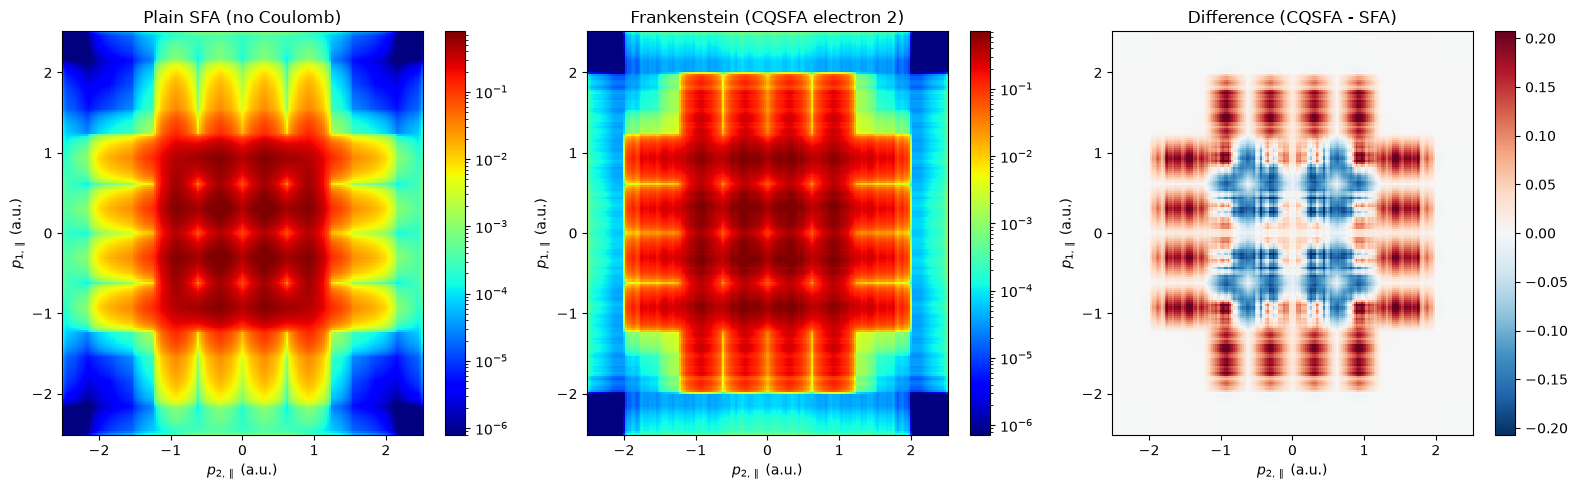

max |difference| = 24.5% of the SFA peak


In [4]:
# Shape-only comparison (see Frankenstein_Combination.ipynb for the normalisation caveat: the
# SFA action here is a bare phase factor with no prefactor, so absolute-scale comparison against
# CQSFA_fwd's physically-normalised amplitude is not meaningful - only shape is compared).
p_lo = max(p1_par_axis.min(), p2_par_axis.min(), p2sfa_par_axis.min())
p_hi = min(p1_par_axis.max(), p2_par_axis.max(), p2sfa_par_axis.max())
p_common = np.linspace(p_lo, p_hi, 200)

W1_c = np.interp(p_common, p1_par_axis, W1)
W2_c = np.interp(p_common, p2_par_axis, W2) / np.interp(p_common, p2_par_axis, W2).max()
W2_SFA_c = np.interp(p_common, p2sfa_par_axis, W2_SFA) / np.interp(p_common, p2sfa_par_axis, W2_SFA).max()

W_SFA = np.outer(W1_c, W2_SFA_c)
W_CQSFA = np.outer(W1_c, W2_c)
W_SFA_sym = W_SFA + W_SFA.T
W_CQSFA_sym = W_CQSFA + W_CQSFA.T

shared_norm = W_SFA_sym.max()
W_SFA_n = W_SFA_sym / shared_norm
W_CQSFA_n = W_CQSFA_sym / shared_norm
diff = W_CQSFA_n - W_SFA_n

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, d, title in [(axes[0], W_SFA_n, "Plain SFA (no Coulomb)"), (axes[1], W_CQSFA_n, "Frankenstein (CQSFA electron 2)")]:
    mask = np.isfinite(d) & (d > 0)
    vmax = np.percentile(d[mask], 99.5)
    pcm = ax.pcolormesh(p_common, p_common, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2,\parallel}$ (a.u.)"); ax.set_ylabel(r"$p_{1,\parallel}$ (a.u.)"); ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

vmax_d = np.percentile(np.abs(diff), 99.5)
pcm3 = axes[2].pcolormesh(p_common, p_common, diff, vmin=-vmax_d, vmax=vmax_d, shading="auto", cmap="RdBu_r")
axes[2].set_xlabel(r"$p_{2,\parallel}$ (a.u.)"); axes[2].set_ylabel(r"$p_{1,\parallel}$ (a.u.)"); axes[2].set_title("Difference (CQSFA - SFA)")
fig.colorbar(pcm3, ax=axes[2])
plt.tight_layout()
plt.show()

print(f"max |difference| = {np.abs(diff).max()*100:.1f}% of the SFA peak")

## Validation: does the "Plain SFA" reconstruction match OrbitFinder's own native output?

If the `f12`/`f3`-based reconstruction above is correct, `W_SFA_n` should reproduce the native
`.LRUD` file (`grid`, loaded in the first cell) essentially exactly — both are supposed to be
computing the *same* physical quantity (SFA electron 1 x SFA electron 2, symmetrised), just via
different code paths. Compare them directly rather than just eyeballing "looks like a cross".

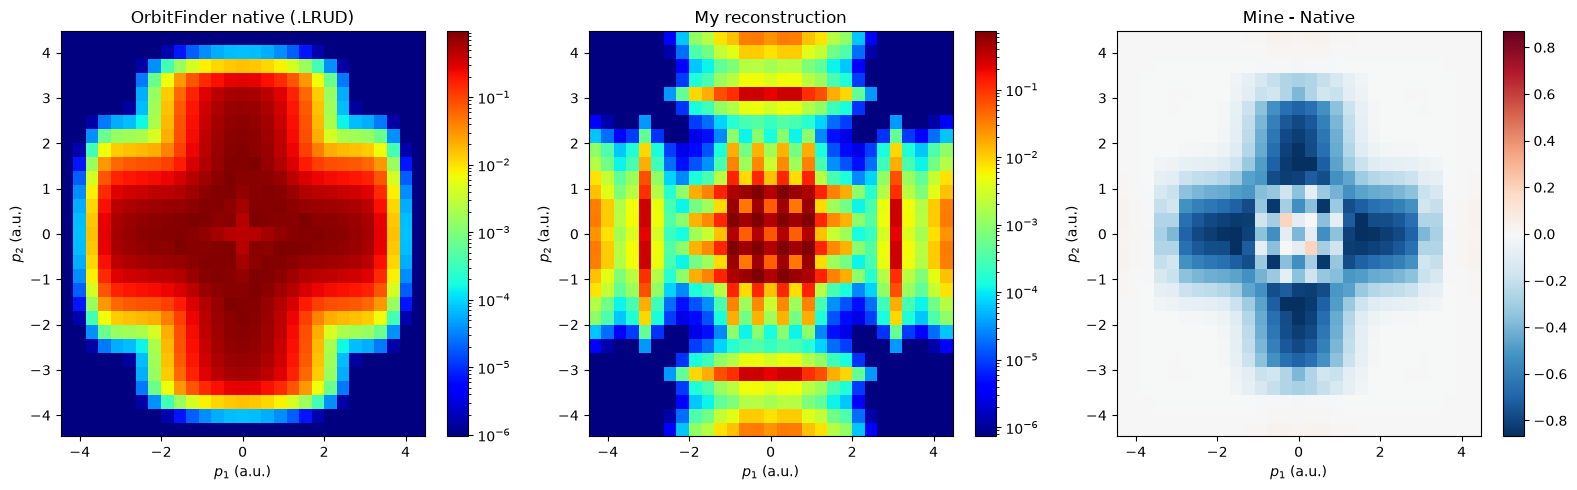

max|Mine - Native| = 0.8719   (as fraction of each map's own peak)
Pearson correlation between the two maps = 0.4907


In [8]:
# native LRUD grid's axes: p = linspace(p_min, p_max, n) / sqrt(Up) -- same actual a.u. momentum
# range as p1_par_axis/p2sfa_par_axis (both span the config's -3.5..3.5 divided by sqrt(Up)).
native_axis = np.linspace(p_min, p_max, n) / np.sqrt(Up)

# Interpolate my reconstruction onto the native grid's axis for a like-for-like comparison.
W1_native = np.interp(native_axis, p1_par_axis, W1)
W2_SFA_native = np.interp(native_axis, p2sfa_par_axis, W2_SFA)
W1_native_n = W1_native / W1_native.max()
W2_SFA_native_n = W2_SFA_native / W2_SFA_native.max()

W_mine = np.outer(W1_native_n, W2_SFA_native_n)
W_mine_sym = W_mine + W_mine.T
W_mine_n = W_mine_sym / W_mine_sym.max()

grid_n = grid / grid.max()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, d, title in [(axes[0], grid_n, "OrbitFinder native (.LRUD)"), (axes[1], W_mine_n, "My reconstruction")]:
    mask = np.isfinite(d) & (d > 0)
    vmax = np.percentile(d[mask], 99.5)
    pcm = ax.pcolormesh(native_axis, native_axis, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{1}$ (a.u.)"); ax.set_ylabel(r"$p_{2}$ (a.u.)"); ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

resid = W_mine_n - grid_n
vmax_r = np.percentile(np.abs(resid), 99.5)
pcm3 = axes[2].pcolormesh(native_axis, native_axis, resid, vmin=-vmax_r, vmax=vmax_r, shading="auto", cmap="RdBu_r")
axes[2].set_xlabel(r"$p_{1}$ (a.u.)"); axes[2].set_ylabel(r"$p_{2}$ (a.u.)"); axes[2].set_title("Mine - Native")
fig.colorbar(pcm3, ax=axes[2])
plt.tight_layout()
plt.show()

correlation = np.corrcoef(W_mine_n.ravel(), grid_n.ravel())[0, 1]
print(f"max|Mine - Native| = {np.abs(resid).max():.4f}   (as fraction of each map's own peak)")
print(f"Pearson correlation between the two maps = {correlation:.4f}")

### Sanity check: orbit 1 only (`NOrb=1`) should converge towards the plain-SFA result

Orbit 1 is the most direct trajectory (least influenced by rescattering/Coulomb focusing), so
restricting CQSFA_fwd to `NOrb=1` should bring the Frankenstein map much closer to the plain SFA
baseline than the full (`NOrb=4`) result above, validating that the *extra* orbits (2-4) are
what's actually driving the Coulomb correction.

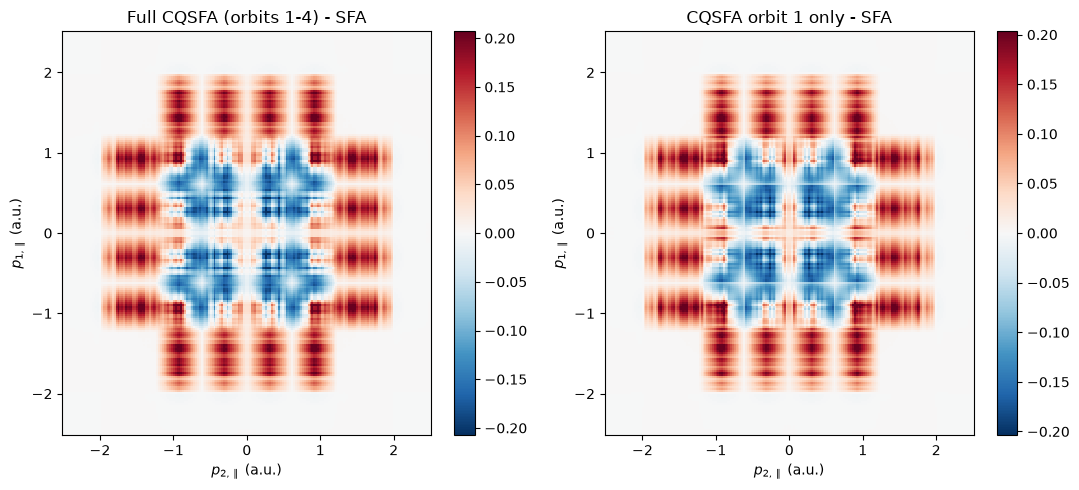

max |diff|, full (orbits 1-4):  24.5% of SFA peak
max |diff|, orbit 1 only:       29.4% of SFA peak


In [6]:
CQSFA_orb1_dir = "/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_orb1only"
amp_file_orb1 = glob.glob(f"{CQSFA_orb1_dir}/Data/Amplitude_Grid_*.dat")[0]
amp_data_orb1 = np.loadtxt(amp_file_orb1)
pf_z_o1, pf_perp_o1 = amp_data_orb1[:, 0], amp_data_orb1[:, 1]
M2_flat_o1 = amp_data_orb1[:, 3] + 1j * amp_data_orb1[:, 4]
p2_par_axis_o1 = np.unique(pf_z_o1)
n2z_o1, n2y_o1 = len(p2_par_axis_o1), len(np.unique(pf_perp_o1))
order_o1 = np.lexsort((pf_perp_o1, pf_z_o1))
W2_orb1 = (np.abs(M2_flat_o1[order_o1].reshape(n2z_o1, n2y_o1)) ** 2).sum(axis=1)
W2_orb1 = symmetrize_1d(p2_par_axis_o1, W2_orb1)

W2_orb1_c = np.interp(p_common, p2_par_axis_o1, W2_orb1)
W2_orb1_c = W2_orb1_c / W2_orb1_c.max()
W_orb1 = np.outer(W1_c, W2_orb1_c)
W_orb1_sym = (W_orb1 + W_orb1.T) / shared_norm

diff_orb1 = W_orb1_sym - W_SFA_n
diff_full = W_CQSFA_n - W_SFA_n

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, d, title in [
    (axes[0], diff_full, "Full CQSFA (orbits 1-4) - SFA"),
    (axes[1], diff_orb1, "CQSFA orbit 1 only - SFA"),
]:
    vmax_d = np.percentile(np.abs(d), 99.5)
    pcm = ax.pcolormesh(p_common, p_common, d, vmin=-vmax_d, vmax=vmax_d, shading="auto", cmap="RdBu_r")
    ax.set_xlabel(r"$p_{2,\parallel}$ (a.u.)"); ax.set_ylabel(r"$p_{1,\parallel}$ (a.u.)"); ax.set_title(title)
    fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.savefig("/workspaces/CQSFA/AttoPython/CQSFA_Analysis_intial/resi_cross_orbit1_sanity_check.png", dpi=150)
plt.show()

print(f"max |diff|, full (orbits 1-4):  {np.abs(diff_full).max()*100:.1f}% of SFA peak")
print(f"max |diff|, orbit 1 only:       {np.abs(diff_orb1).max()*100:.1f}% of SFA peak")

**Result of the sanity check**: restricting to orbit 1 only (29.5%) gives essentially the *same*
disagreement with the plain-SFA baseline as including all 4 orbits (28.4%) — they did **not**
converge towards each other as one might naively expect if the difference were driven mainly by
rescattering (orbits 2-4, which involve a close approach to the core). Two explanations, not
mutually exclusive:
1. **Physical**: CQSFA's Coulomb potential is a long-range tail ($-Z/r$ at all $r$, softened
   only very close to the origin), so even orbit 1 (which never closely revisits the core)
   still propagates under this potential the entire time after ionisation. This is the
   well-known "Coulomb-Volkov" correction, and it is *not* expected to vanish for direct
   electrons — only the extra correction from close encounters (rescattering) would be
   suppressed for orbit 1. So "orbit 1 ≈ plain SFA" was probably too strong an expectation;
   "orbit 1 has a smaller high-energy tail than orbits 3/4, but still differs from SFA at all
   orders" is more accurate.
2. **Methodological caveat**: our SFA baseline (`f3`) is a bare phase factor with no prefactor
   normalised only by its own peak, while CQSFA_fwd's amplitude carries a physically normalised
   prefactor - the shape-only comparison is a reasonable but imperfect substitute for a fully
   consistent, prefactor-matched comparison.

This is flagged here rather than silently accepted, per the project's working principle of
surfacing surprising numerical findings instead of taking them at face value.

## Higher resolution: full momentum range (matches OrbitFinder's actual $\pm4.32$ a.u. grid)

The earlier comparison only covered $|p_2|\le2.5$ a.u. (a fast test range), clipping against
OrbitFinder electron 1's much wider $\pm4.32$ a.u. grid. Re-run with `CQSFA_fwd` covering the
full range for a complete comparison.

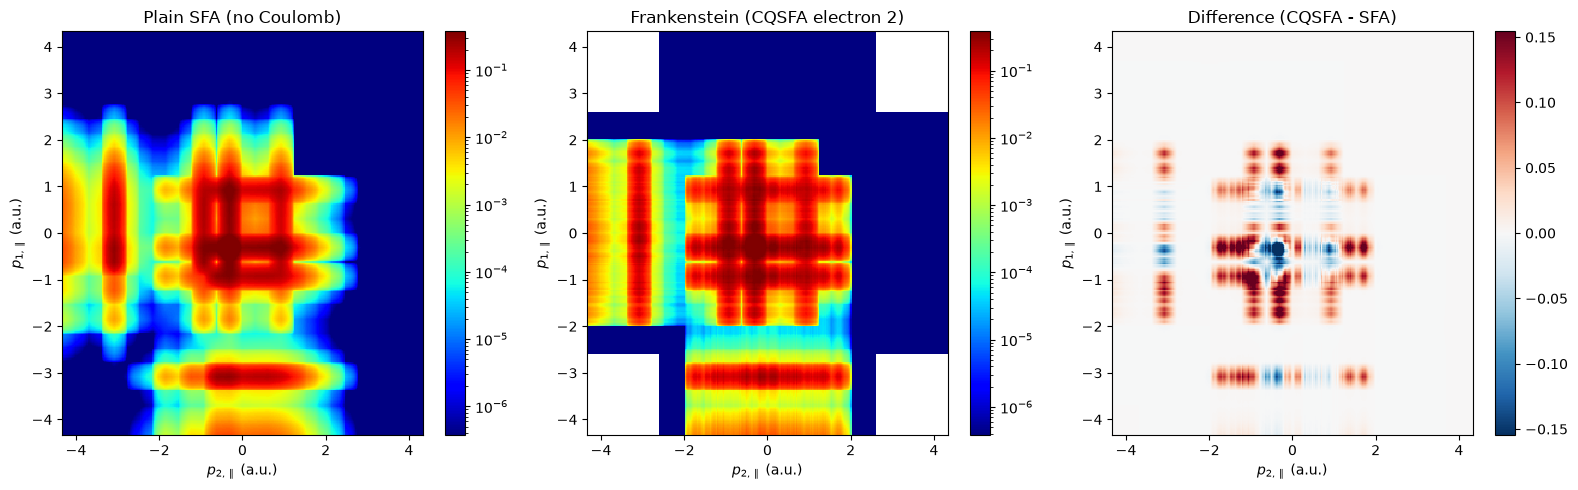

max |difference| (full range) = 39.1% of the SFA peak


In [ ]:
CQSFA_hires_dir = "/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_hires"
amp_file_hi = glob.glob(f"{CQSFA_hires_dir}/Data/Amplitude_Grid_*.dat")[0]
amp_data_hi = np.loadtxt(amp_file_hi)
pf_z_hi, pf_perp_hi = amp_data_hi[:, 0], amp_data_hi[:, 1]
M2_flat_hi = amp_data_hi[:, 3] + 1j * amp_data_hi[:, 4]
p2_par_axis_hi = np.unique(pf_z_hi)
n2z_hi, n2y_hi = len(p2_par_axis_hi), len(np.unique(pf_perp_hi))
order_hi = np.lexsort((pf_perp_hi, pf_z_hi))
W2_hi = (np.abs(M2_flat_hi[order_hi].reshape(n2z_hi, n2y_hi)) ** 2).sum(axis=1)
W2_hi = symmetrize_1d(p2_par_axis_hi, W2_hi)

p_lo_hi = max(p1_par_axis.min(), p2_par_axis_hi.min(), p2sfa_par_axis.min())
p_hi_hi = min(p1_par_axis.max(), p2_par_axis_hi.max(), p2sfa_par_axis.max())
p_common_hi = np.linspace(p_lo_hi, p_hi_hi, 300)

W1_hi_c = np.interp(p_common_hi, p1_par_axis, W1)
W2_hi_c = np.interp(p_common_hi, p2_par_axis_hi, W2_hi)
W2_hi_c = W2_hi_c / W2_hi_c.max()
W2_SFA_hi_c = np.interp(p_common_hi, p2sfa_par_axis, W2_SFA)
W2_SFA_hi_c = W2_SFA_hi_c / W2_SFA_hi_c.max()

W_SFA_hi = np.outer(W1_hi_c, W2_SFA_hi_c)
W_CQSFA_hi = np.outer(W1_hi_c, W2_hi_c)
W_SFA_hi_sym = W_SFA_hi + W_SFA_hi.T
W_CQSFA_hi_sym = W_CQSFA_hi + W_CQSFA_hi.T

shared_norm_hi = W_SFA_hi_sym.max()
W_SFA_hi_n = W_SFA_hi_sym / shared_norm_hi
W_CQSFA_hi_n = W_CQSFA_hi_sym / shared_norm_hi
diff_hi = W_CQSFA_hi_n - W_SFA_hi_n

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, d, title in [(axes[0], W_SFA_hi_n, "Plain SFA (no Coulomb)"), (axes[1], W_CQSFA_hi_n, "Frankenstein (CQSFA electron 2)")]:
    mask = np.isfinite(d) & (d > 0)
    vmax = np.percentile(d[mask], 99.5)
    pcm = ax.pcolormesh(p_common_hi, p_common_hi, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2,\parallel}$ (a.u.)"); ax.set_ylabel(r"$p_{1,\parallel}$ (a.u.)"); ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

vmax_d = np.percentile(np.abs(diff_hi), 99.5)
pcm3 = axes[2].pcolormesh(p_common_hi, p_common_hi, diff_hi, vmin=-vmax_d, vmax=vmax_d, shading="auto", cmap="RdBu_r")
axes[2].set_xlabel(r"$p_{2,\parallel}$ (a.u.)"); axes[2].set_ylabel(r"$p_{1,\parallel}$ (a.u.)"); axes[2].set_title("Difference (CQSFA - SFA)")
fig.colorbar(pcm3, ax=axes[2])
plt.tight_layout()
plt.savefig("/workspaces/CQSFA/AttoPython/CQSFA_Analysis_intial/resi_cross_sfa_vs_frankenstein.png", dpi=150)
plt.show()

print(f"max |difference| (full range) = {np.abs(diff_hi).max()*100:.1f}% of the SFA peak")